In [2]:
import numpy as np
from skimage.feature import hog

In [3]:
def load_data(path, isImage):

    with open(path, 'rb') as f:
        data = f.read()
        
    magic = int.from_bytes(data[0:4], 'big')
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if isImage:
        offset = 16  # images have 16-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        arr = arr.reshape(num_images, rows, cols)
    else:
        offset = 8  # labels have 8-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        
    return arr


def load_mnist():
    x_train = load_data("../../data/mnist_dataset/train-images-idx3-ubyte", True)
    y_train = load_data("../../data/mnist_dataset/train-labels-idx1-ubyte", False)
    x_test  = load_data("../../data/mnist_dataset/t10k-images-idx3-ubyte", True)
    y_test  = load_data("../../data/mnist_dataset/t10k-labels-idx1-ubyte", False)
    return x_train, y_train, x_test, y_test

In [4]:
x_train, y_train, x_test, y_test = load_mnist()

In [5]:
def data_preprocessing(x_train_split, x_val_split):
    return x_train_split/255.0, x_val_split/255.0

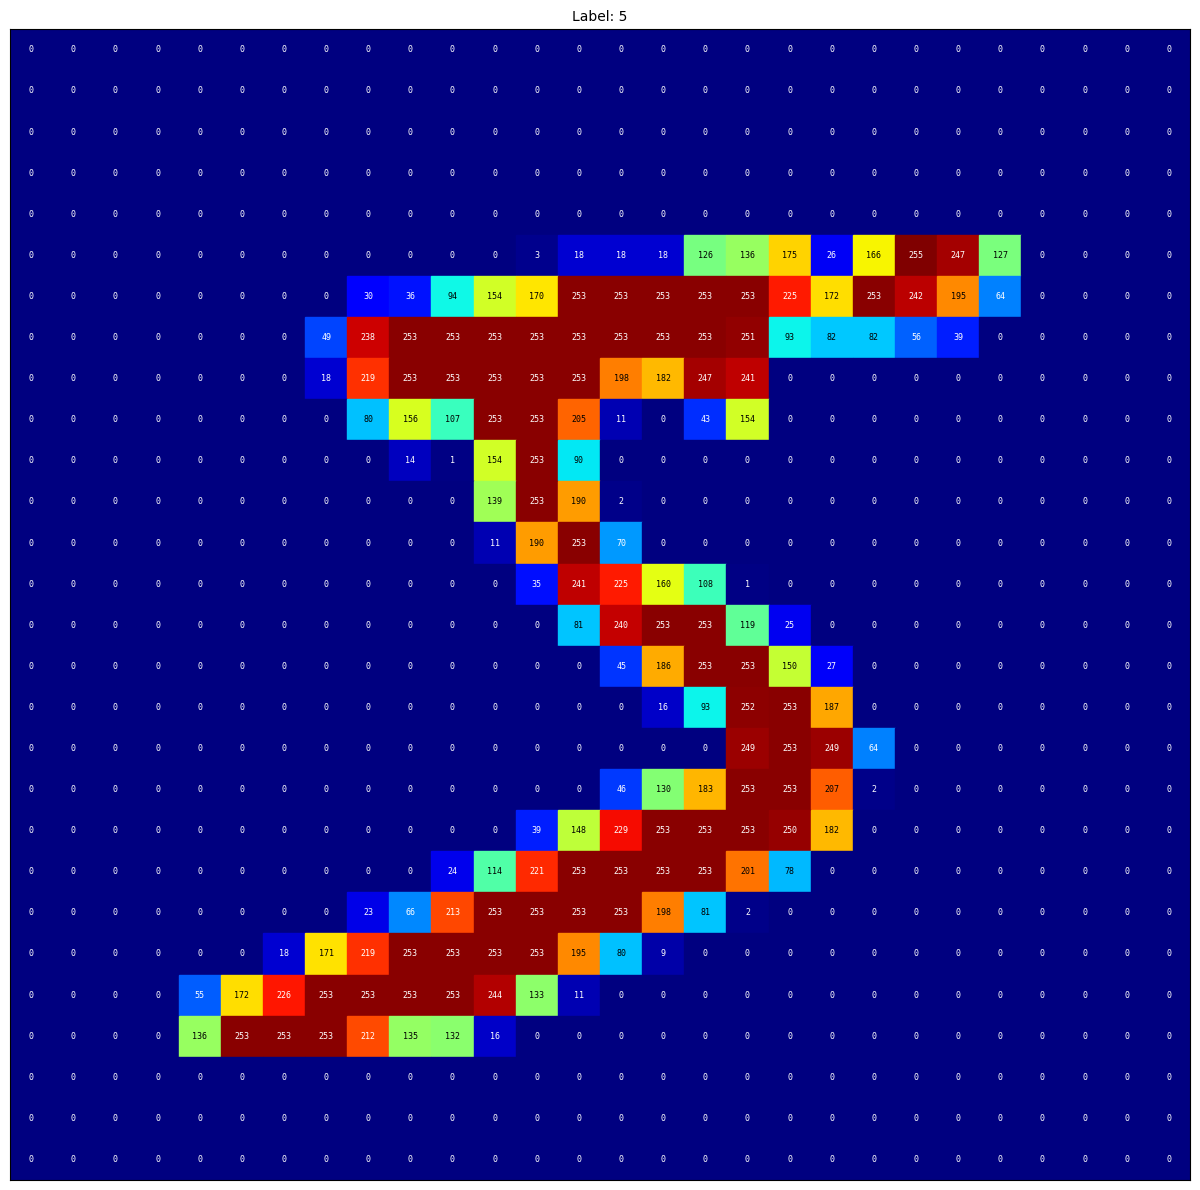

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

num_images = 1
cols = 3
rows = math.ceil(num_images / cols)
cmap = plt.cm.jet  # or: plt.cm.hot, plt.cm.viridis, etc.

fig, axes = plt.subplots(rows, cols, figsize=(cols * 12, rows * 12))
axes = axes.flatten()

for i in range(num_images):
    ax = axes[i]
    img = x_train[i]  # shape: (28, 28), values 0–255

    # Normalize to [0, 1] for colormap
    norm_img = img / 255.0

    for row in range(28):
        for col in range(28):
            val = img[row, col]
            t = val / 255.0
            color = cmap(t)
            # Pick white or black text based on background luminance
            lum = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            text_color = 'black' if lum > 0.5 else 'white'
            ax.text(col, row, str(val),
                    ha='center', va='center',
                    fontsize=6, color=text_color,
                    fontfamily='monospace')
            ax.add_patch(plt.Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                color=color, zorder=0
            ))

    ax.set_xlim(-0.5, 27.5)
    ax.set_ylim(27.5, -0.5)  # flip y so row 0 is at top
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Label: {y_train[i]}", fontsize=10)

# Hide unused subplots
for j in range(num_images, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("pixel_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

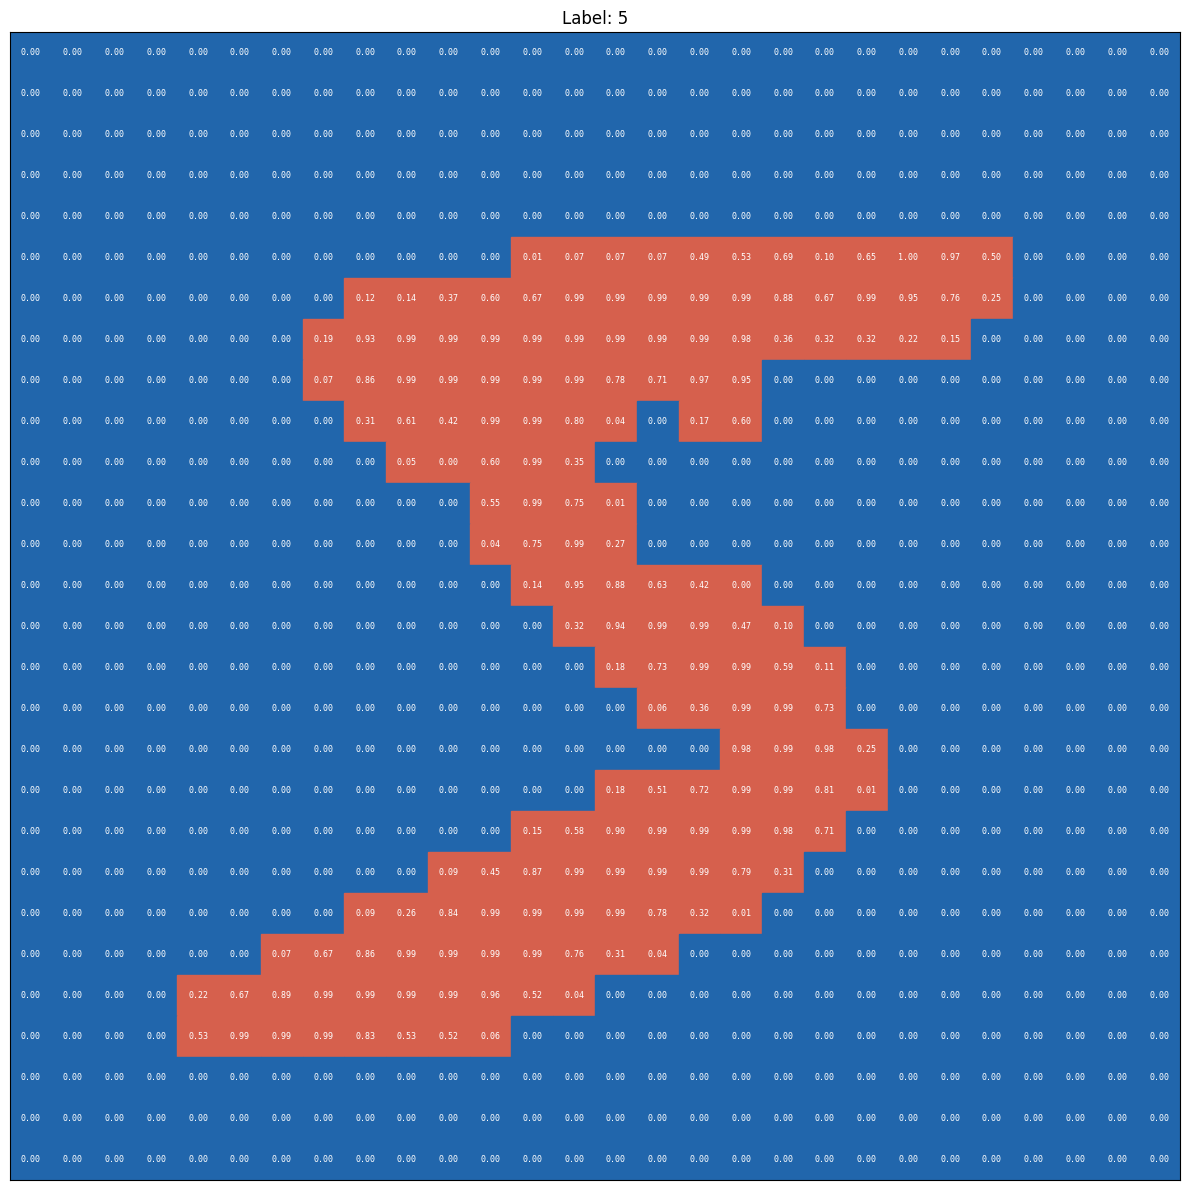

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import math

num_images = 1
cols = 1
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.array([axes]).flatten()

for i in range(num_images):
    ax = axes[i]
    img = x_train[i] / 255.0  # shape: (28, 28), values 0.0–1.0

    for row in range(28):
        for col in range(28):
            val = img[row, col]
            is_zero = val == 0.0
            bg_color = '#2166ac' if is_zero else '#d6604d'  # blue : red
            text_color = 'white'
            ax.add_patch(plt.Rectangle(
                (col - 0.5, row - 0.5), 1, 1,
                color=bg_color, zorder=0
            ))
            ax.text(col, row, f"{val:.2f}",
                    ha='center', va='center',
                    fontsize=6, color=text_color,
                    fontfamily='monospace')

    ax.set_xlim(-0.5, 27.5)
    ax.set_ylim(27.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Label: {y_train[i]}", fontsize=12)

plt.tight_layout()
plt.savefig("pixel_heatmap_normalized.png", dpi=150, bbox_inches='tight')
plt.show()

In [41]:
def data_preprocessing_hog(x_train, x_val, n_components=0.95):
    x_train_hog = np.array([hog(img, orientations=9, pixels_per_cell=(8, 8), 
                                cells_per_block=(2, 2)) for img in x_train])

    x_val_hog = np.array([hog(img, orientations=9, pixels_per_cell=(8, 8), 
                              cells_per_block=(2, 2)) for img in x_val])
    
    # 2. Manual L2 Normalization (as you requested)
    x_train_norm = x_train_hog / (np.linalg.norm(x_train_hog, axis=1, keepdims=True) + 1e-8)
    x_val_norm = x_val_hog / (np.linalg.norm(x_val_hog, axis=1, keepdims=True) + 1e-8)

    
    return x_train_norm, x_val_norm

In [ ]:
def data_distribution(x_train, y_train, model_digit):
    x_train_raw, x_val_raw = x_train[:50000], x_train[50000:]
    y_train_raw, y_val_raw = y_train[:50000], y_train[50000:]

    return x_train_raw, y_train_raw, x_val_raw, y_val_raw

In [ ]:
def logistic_regression(x_train, y_train, model_digit, batch_size=32, learning_rate=0.01, validation_patience=5, epsilon=1e-4):
    
    x_train_split, y_train_split, x_val, y_val = data_distribution(x_train, y_train, model_digit)

    x_train_split, x_val = data_preprocessing_hog(x_train_split, x_val)

    y_train_split = (y_train_split == model_digit).astype(float).reshape(-1, 1)
    y_val = (y_val == model_digit).astype(float).reshape(-1, 1)
    
    x_train_flat = x_train_split.reshape(x_train_split.shape[0], -1) # (split, 784)
    x_train_bias = np.hstack([x_train_flat, np.ones((x_train_split.shape[0], 1))]) # (split, 785)

    x_val_flat = x_val.reshape(x_val.shape[0], -1)  # (split', 784)
    x_val_bias = np.hstack([x_val_flat, np.ones((x_val.shape[0], 1))]) # (split', 785)


    w = np.random.uniform(low=-0.01, high=0.01, size=(x_train_bias.shape[1], 1))
    best_v_loss = float('inf')
    best_w = w.copy()
    patience = validation_patience
    counter = 0
    epoch = 0

    N = x_train_bias.shape[0]
    n_pos = np.sum(y_train_split == 1)
    n_neg = N - n_pos

    # Note dividing by 2 is esential to keep the overall average weight at 1
    # hence keeping the same learning rate scale as if we were doing unweighted logistic regression
    w_pos = N / (2 * n_pos)
    w_neg = N / (2 * n_neg)

    max_epochs = 100
    while epoch < max_epochs:
        #Since we are doing Mini-batch gradient descent, 
        # we need to shuffle the data to prevent the model from learning the order of the data.
        indices = np.random.permutation(N)
        x_shuffled = x_train_bias[indices]
        y_shuffled = y_train_split[indices]

        for start in range(0, N, batch_size):

            end   = min(start + batch_size, N)
            
            xi_batch = x_shuffled[start:end]          # (B, 785)
            yi_batch = y_shuffled[start:end]          # (B, 1)

            z_batch  = np.dot(xi_batch, w)            # (B, 1)
            y_hat    = 1 / (1 + np.exp(-z_batch))     # (B, 1)

            sample_weights = yi_batch * w_pos + (1 - yi_batch) * w_neg
            error   = (y_hat - y_shuffled[start:end]) * sample_weights   # (B, 1)
            de_dw   = np.dot(xi_batch.T, error) / xi_batch.shape[0]  # (785, 1)
            w      -= learning_rate * de_dw
            
        z_v = np.dot(x_val_bias, w) #split'x785 * 785x1
        y_hat_v = 1 / (1 + np.exp(-z_v))

        y_hat_v = np.clip(y_hat_v, 1e-15, 1 - 1e-15) # Cap to avoid log(0) errors

        v_loss = -np.mean(y_val * np.log(y_hat_v) + (1 - y_val) * np.log(1 - y_hat_v))

        if v_loss < best_v_loss - epsilon:
            best_v_loss = v_loss
            best_w = w.copy()
            counter = 0
        else:
            counter += 1

        if counter == patience:
            return best_w
        print(f"Epoch: {epoch}, Loss:  {v_loss}")

        epoch += 1

        if(epoch == max_epochs):
            print("Reached maximum epochs. Stopping training...")
            return best_w


In [48]:
weights = logistic_regression(x_train, y_train, 5, 16, 0.05, 20, 1e-10)

Epoch: 0, Loss:  0.3048624909918636
Epoch: 1, Loss:  0.2273496231031603
Epoch: 2, Loss:  0.17960664449249233
Epoch: 3, Loss:  0.1620839220428528
Epoch: 4, Loss:  0.1507297338212221
Epoch: 5, Loss:  0.14203132841289368
Epoch: 6, Loss:  0.13508194548702926
Epoch: 7, Loss:  0.12385801614012937
Epoch: 8, Loss:  0.12152768223273311
Epoch: 9, Loss:  0.13305913576293452
Epoch: 10, Loss:  0.1153849693035836
Epoch: 11, Loss:  0.11466174403098196
Epoch: 12, Loss:  0.11259748419345456
Epoch: 13, Loss:  0.1208179108887425
Epoch: 14, Loss:  0.11101311876026662
Epoch: 15, Loss:  0.11313448469684081
Epoch: 16, Loss:  0.10516101658479465
Epoch: 17, Loss:  0.10512309876599779
Epoch: 18, Loss:  0.10025987732379003
Epoch: 19, Loss:  0.10154880154790373
Epoch: 20, Loss:  0.09406186680895398
Epoch: 21, Loss:  0.10247282759049385
Epoch: 22, Loss:  0.09845641763797797
Epoch: 23, Loss:  0.09231115920241045
Epoch: 24, Loss:  0.09789174043502999
Epoch: 25, Loss:  0.09883529239368812
Epoch: 26, Loss:  0.10146419

Results for digit 5 (threshold=0.5):
  Accuracy:  96.88%
  Precision: 0.7539
  Recall:    0.9652
  F1 Score:  0.8466

Confusion Matrix:
[[  31  281]
 [ 861 8827]]


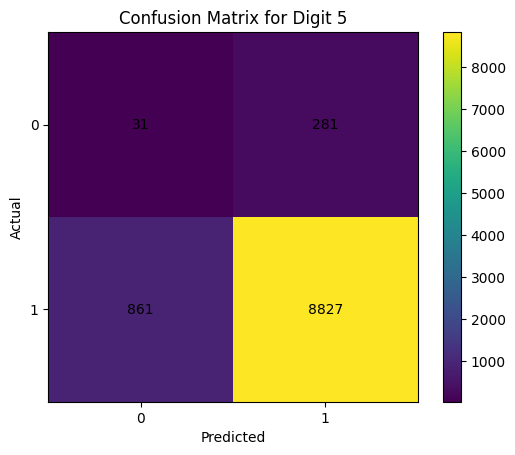

In [49]:
import matplotlib.pyplot as plt
def predict(x_test, y_test, model_digit, w, threshold=0.5):
    # Compute HOG features
    x_test_hog, _ = data_preprocessing_hog(x_test, x_test)  # We only need the HOG features, not PCA here
    

    
    x_test_flat = x_test_hog.reshape(x_test_hog.shape[0], -1)
    x_test_bias = np.hstack([x_test_flat, np.ones((x_test_hog.shape[0], 1))])

    # Forward pass
    z = np.dot(x_test_bias, w)
    y_hat = 1 / (1 + np.exp(-z))

    # Binary labels for this digit
    y_true = (y_test == model_digit).astype(float).reshape(-1, 1)

    # Predictions: use provided threshold
    y_pred = (y_hat >= threshold).astype(float)

    correct = np.sum(y_pred == y_true)
    accuracy = correct / len(y_true) * 100

    true_positives  = np.sum((y_pred == 1) & (y_true == 1))
    false_positives = np.sum((y_pred == 1) & (y_true == 0))
    false_negatives = np.sum((y_pred == 0) & (y_true == 1))
    true_negatives  = np.sum((y_pred == 0) & (y_true == 0))
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall    = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Results for digit {model_digit} (threshold={threshold}):")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

    cm = np.array([[false_negatives, false_positives],
                   [true_positives, true_negatives]])
    print("\nConfusion Matrix:")
    print(cm)

    # Optional: Plot it
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix for Digit {model_digit}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # Add text annotations
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.xticks([0, 1], ['0', '1'])
    plt.yticks([0, 1], ['0', '1'])
    plt.colorbar()
    plt.show()
digit = 5
predict(x_test, y_test, digit, weights, threshold=0.5)

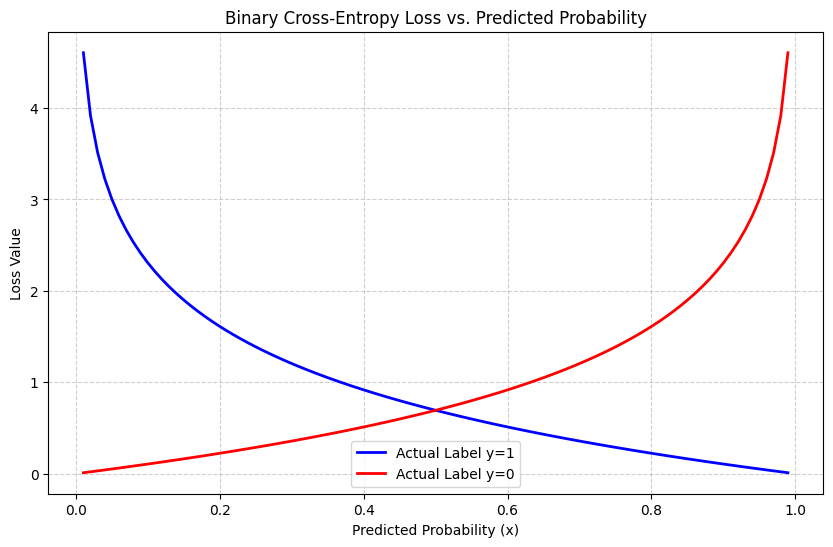

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 0.99, 100)

loss_y1 = -np.log(x)           
loss_y0 = -np.log(1 - x)      

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, loss_y1, label='Actual Label y=1', color='blue', lw=2)
plt.plot(x, loss_y0, label='Actual Label y=0', color='red', lw=2)

plt.title('Binary Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

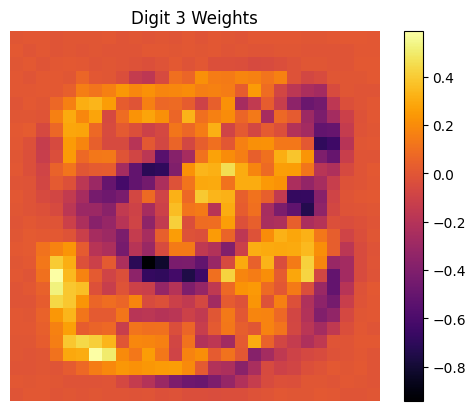

In [10]:
import matplotlib.pyplot as plt

def visualize_weights(w, title="Weight Visualization"):
    # Remove bias term
    w_no_bias = w[:-1]  # (784,)

    # Reshape into 28x28 image
    img = w_no_bias.reshape(28, 28)

    # Plot
    plt.figure()
    plt.imshow(img, cmap='inferno')  # orange heatmap style
    plt.colorbar()
    plt.title(title)
    plt.axis('off')
    plt.show()
    
digit = 3
visualize_weights(weights, title=f"Digit {digit} Weights")